In [1]:
import os
from pathlib import Path

# Ensure CWD is repo root so relative paths and ``research.*`` imports resolve.
if Path.cwd().name == "notebooks":
    os.chdir("..")


# Análise Exploratória — Auditoria Cleanlab no DeciContas

Este *notebook* documenta o procedimento de auditoria que produziu o **DeciContas-861-corrected** a partir do gold original do **DeciContas-861**. O processo combinou:

1. um *ensemble* de dois modelos complementares (BERTimbau-base *fine-tuned* + classificador linear sobre *embeddings* BERTimbau-Large) para gerar probabilidades fora da partição de treino, via validação cruzada estratificada de 5 *folds*;
2. a biblioteca **Cleanlab** (*Confident Learning*; Northcutt et al., 2022) sobre essas probabilidades para sinalizar grupos de *tokens* potencialmente mal anotados;
3. uma revisão humana, *grupo a grupo*, dos sinalizados acima do limiar de confiança ≥ 0,95 do *ensemble*; demais grupos foram mantidos na anotação original.

O artefato final dessa revisão é `dataset/errors/dataset-corrections.json` (v2, 4.199 mudanças *token*-nível, 567/794 grupos revisados). Este notebook reproduz a EDA sobre esse JSON, mostrando as distribuições, as transições principais de rótulo e exemplos concretos.


In [2]:
import json
from collections import Counter, defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from research.dataset_io import load_dataset
from research.release.apply_corrections import load_corrections

sns.set_theme(style="whitegrid")
plt.rcParams.update({"font.size": 10})

CORRECTIONS_PATH = Path("dataset/errors/dataset-corrections.json")
REPORT_DIR = Path("dataset/results/chapter5_corrected")

payload = json.loads(CORRECTIONS_PATH.read_text(encoding="utf-8"))
summary = payload.get("summary", {})
print("Versão do JSON de correções:", payload.get("version"))
print("Gerado em:", payload.get("generated_at"))
summary_df = pd.DataFrame(summary.items(), columns=["métrica", "valor"])
summary_df


Versão do JSON de correções: 2
Gerado em: 2026-05-05T18:16:47.908806+00:00


,métrica,valor
0,groups_total,794
1,groups_decided,567
2,accept,6
3,reject,544
4,custom,17
5,mixed,0
6,token_changes,4199
7,unmapped_total,0
8,unmapped_decided,0


## 1. Decisões agregadas

Cada *token* sinalizado entra em um *grupo de entidade* (sequência contígua que forma uma entidade). O revisor decide o grupo todo, não cada *token* isolado, escolhendo uma de três ações:

- **accept**: aceita a sugestão do Cleanlab (substitui o gold pelo `label_sugerido`);
- **reject**: rejeita a sugestão e mantém o `label_original`;
- **custom**: rescreve o rótulo manualmente (com possível ajuste de fronteira do *span*).


In [3]:
changes = payload.get("token_changes", [])
df_changes = pd.DataFrame(changes)
print(f"Total de mudanças token-nível: {len(df_changes)}")

decision_counts = df_changes["decision"].value_counts().rename_axis("decision").reset_index(name="count")
decision_counts


Total de mudanças token-nível: 4199


,decision,count
0,reject,3238
1,custom,778
2,accept,183


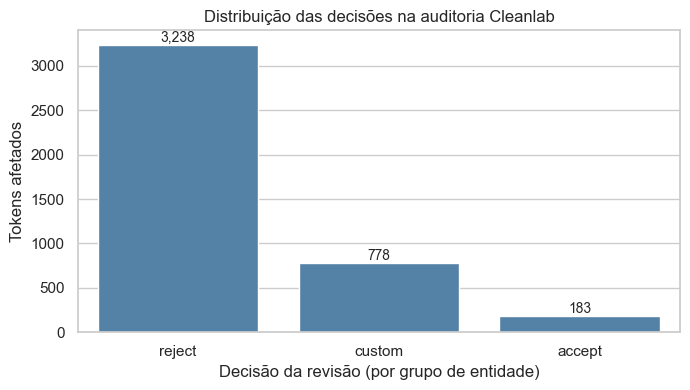

In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(
    decision_counts.sort_values("count", ascending=False),
    x="decision", y="count", ax=ax, color="steelblue",
)
ax.set_xlabel("Decisão da revisão (por grupo de entidade)")
ax.set_ylabel("Tokens afetados")
ax.set_title("Distribuição das decisões na auditoria Cleanlab")
for i, c in enumerate(decision_counts.sort_values("count", ascending=False)["count"]):
    ax.text(i, c, f"{c:,}", ha="center", va="bottom")
plt.tight_layout(); plt.show()


## 2. Distribuição de `label_final`

`label_final` é o rótulo BIO efetivo que cada *token* ganhou após a revisão. Concentrações em `O` indicam grupos onde a revisão removeu entidades infladas (típico de modelos LLM com fronteiras longas demais).

/var/folders/39/p0t9g2qn1gbcvnwqyz79d34c0000gn/T/ipykernel_81386/4090288130.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")


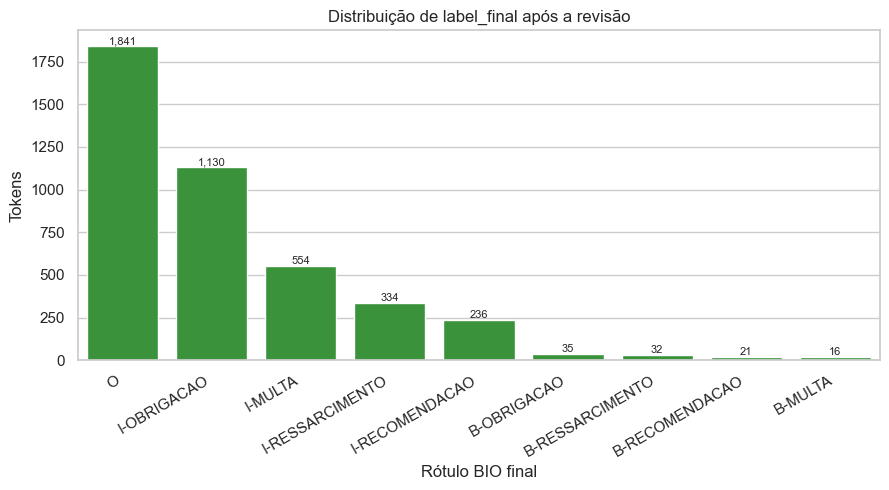

,label_final,count
0,O,1841
1,I-OBRIGACAO,1130
2,I-MULTA,554
3,I-RESSARCIMENTO,334
4,I-RECOMENDACAO,236
5,B-OBRIGACAO,35
6,B-RESSARCIMENTO,32
7,B-RECOMENDACAO,21
8,B-MULTA,16


In [5]:
label_final_counts = df_changes["label_final"].value_counts().rename_axis("label_final").reset_index(name="count")
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(
    label_final_counts.sort_values("count", ascending=False),
    x="label_final", y="count", ax=ax, color="#2ca02c",
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
ax.set_xlabel("Rótulo BIO final")
ax.set_ylabel("Tokens")
ax.set_title("Distribuição de label_final após a revisão")
for i, c in enumerate(label_final_counts.sort_values("count", ascending=False)["count"]):
    ax.text(i, c, f"{c:,}", ha="center", va="bottom", fontsize=8)
plt.tight_layout(); plt.show()
label_final_counts


## 3. Saldo líquido por classe

Diferença em número de **entidades** (spans), não de *tokens*, entre o gold original (DeciContas-861) e o corrigido. Sintetiza o efeito das correções sobre a distribuição final do *corpus*.

In [6]:
delta = pd.read_csv(REPORT_DIR / "B_class_delta.csv")
delta


,label,before,after,delta
0,MULTA,202,212,10
1,OBRIGACAO,119,131,12
2,RECOMENDACAO,56,53,-3
3,RESSARCIMENTO,62,63,1


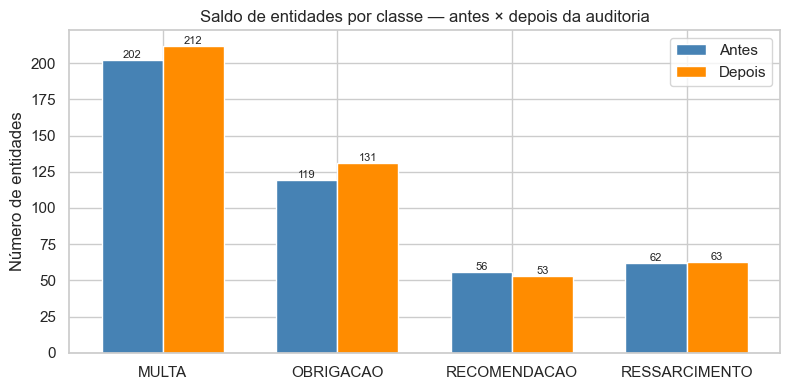

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(delta))
w = 0.35
ax.bar(x - w/2, delta["before"], w, label="Antes", color="steelblue")
ax.bar(x + w/2, delta["after"], w, label="Depois", color="darkorange")
for i, (b, a) in enumerate(zip(delta["before"], delta["after"])):
    ax.text(i - w/2, b, str(b), ha="center", va="bottom", fontsize=8)
    ax.text(i + w/2, a, str(a), ha="center", va="bottom", fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(delta["label"])
ax.set_ylabel("Número de entidades")
ax.set_title("Saldo de entidades por classe — antes × depois da auditoria")
ax.legend()
plt.tight_layout(); plt.show()


## 4. Matriz de transições rótulo original → rótulo final

Para cada *token* alterado, registramos a transição `(label_original, label_final)`. Os arcos mais carregados indicam onde o gold original e o modelo *ensemble* mais divergiam — geralmente nas fronteiras finais de OBRIGAÇÃO/MULTA, onde os anotadores originais incluíam fundamentação legal junto ao dispositivo.

In [8]:
# O dataset-corrections.json não armazena label_original por token; recuperamos
# percorrendo o dataset gold original e olhando o BIO no índice (document_id, token_idx).
ds_pre = load_dataset(Path("dataset/release/decicontas-861/decicontas-labelstudio.json"))
tokens_by_doc = {d.document_id: d.tokens for d in ds_pre.documents}

transitions: Counter = Counter()
for ch in changes:
    doc_id = int(ch["document_id"])
    idx = int(ch["token_idx_in_doc"])
    label_final = ch["label_final"]
    toks = tokens_by_doc.get(doc_id)
    if toks is None or idx >= len(toks):
        continue
    label_original = toks[idx].bio
    transitions[(label_original, label_final)] += 1

df_trans = (
    pd.DataFrame(
        [{"from": a, "to": b, "count": c} for (a, b), c in transitions.items()]
    )
    .sort_values("count", ascending=False)
    .reset_index(drop=True)
)
print(f"Total de pares de transição distintos: {len(df_trans)}")
df_trans.head(15)


Total de pares de transição distintos: 28


,from,to,count
0,O,O,1638
1,I-OBRIGACAO,I-OBRIGACAO,710
2,I-MULTA,I-MULTA,441
3,O,I-OBRIGACAO,406
4,I-RESSARCIMENTO,I-RESSARCIMENTO,258
5,I-RECOMENDACAO,I-RECOMENDACAO,178
6,I-RECOMENDACAO,O,141
7,O,I-MULTA,112
8,O,I-RESSARCIMENTO,76
9,O,I-RECOMENDACAO,58


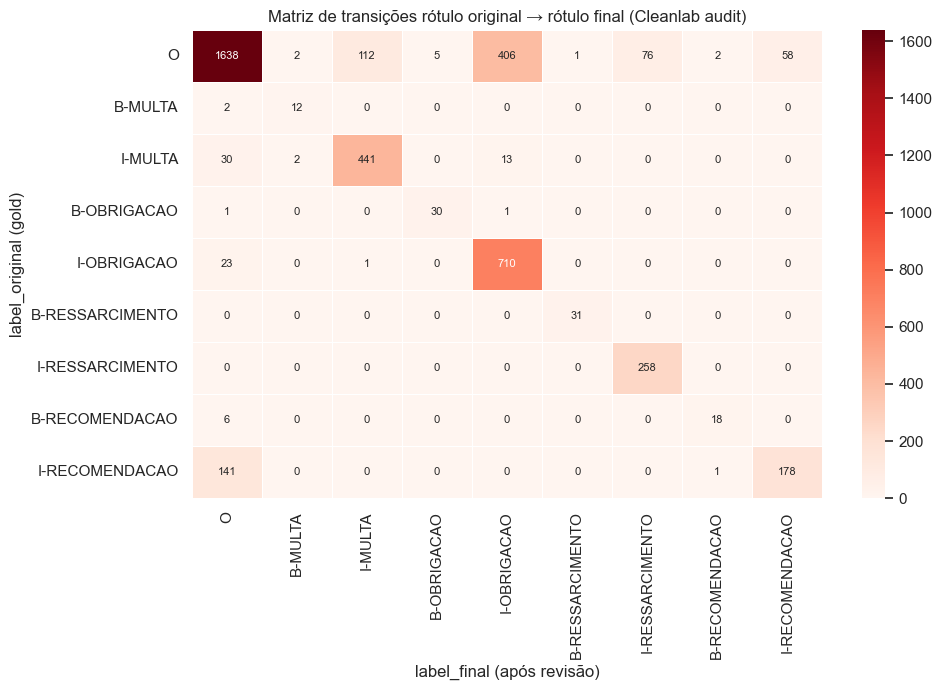

In [9]:
# Heatmap rótulo original × rótulo final
labels_order = ["O", "B-MULTA", "I-MULTA", "B-OBRIGACAO", "I-OBRIGACAO",
                "B-RESSARCIMENTO", "I-RESSARCIMENTO", "B-RECOMENDACAO", "I-RECOMENDACAO"]
mat = pd.DataFrame(0, index=labels_order, columns=labels_order, dtype=int)
for (a, b), c in transitions.items():
    if a in mat.index and b in mat.columns:
        mat.loc[a, b] = c
fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(
    mat, annot=True, fmt="d", cmap="Reds", linewidths=0.5, ax=ax, cbar=True,
    annot_kws={"fontsize": 8},
)
ax.set_xlabel("label_final (após revisão)")
ax.set_ylabel("label_original (gold)")
ax.set_title("Matriz de transições rótulo original → rótulo final (Cleanlab audit)")
plt.tight_layout(); plt.show()


## 5. Top documentos com mais correções

Identifica os documentos onde a auditoria mais interveio. Útil para amostragem de inspeção qualitativa (ex.: confirmar que o limiar de 0,95 não introduziu correções abusivas).

In [10]:
by_doc = df_changes.groupby("document_id").size().sort_values(ascending=False).head(10).rename("tokens_altered")
by_doc = by_doc.reset_index()
by_doc


,document_id,tokens_altered
0,497,256
1,410,175
2,596,142
3,225,131
4,780,130
5,840,129
6,631,106
7,232,106
8,95,103
9,339,98


In [11]:
# Exemplo qualitativo do doc mais corrigido
top_doc_id = int(by_doc.iloc[0]["document_id"])
doc_pre = next(d for d in ds_pre.documents if d.document_id == top_doc_id)
tok_changes_doc = [ch for ch in changes if ch["document_id"] == top_doc_id]
print(f"Doc {top_doc_id}: {len(doc_pre.tokens)} tokens, {len(tok_changes_doc)} alterações")
print("\nPrimeiras 200 chars do texto:")
print(doc_pre.text[:200], "...")

rows_q = []
for ch in tok_changes_doc[:20]:
    idx = int(ch["token_idx_in_doc"])
    rows_q.append({
        "token_idx": idx,
        "token": doc_pre.tokens[idx].text if idx < len(doc_pre.tokens) else "",
        "label_original": doc_pre.tokens[idx].bio if idx < len(doc_pre.tokens) else "",
        "label_final": ch["label_final"],
        "decision": ch["decision"],
    })
pd.DataFrame(rows_q)


Doc 497: 1056 tokens, 256 alterações

Primeiras 200 chars do texto:
Vistos, relatados e discutidos estes autos,  concordando parcialmente com o Corpo Técnico e o Ministério Público de Contas, ACORDAM os Conselheiros, nos termos do voto proferido pelo Conselheiro Relat ...


,token_idx,token,label_original,label_final,decision
0,215,(dezoito),I-OBRIGACAO,I-OBRIGACAO,reject
1,216,"meses,",I-OBRIGACAO,I-OBRIGACAO,reject
2,225,o,I-OBRIGACAO,I-OBRIGACAO,reject
3,228,Lagoa,I-OBRIGACAO,I-OBRIGACAO,reject
4,229,Nova,I-OBRIGACAO,I-OBRIGACAO,reject
5,234,estiver,I-OBRIGACAO,I-OBRIGACAO,reject
6,235,no,I-OBRIGACAO,I-OBRIGACAO,reject
7,236,exercício,I-OBRIGACAO,I-OBRIGACAO,reject
8,237,do,I-OBRIGACAO,I-OBRIGACAO,reject
9,238,cargo,I-OBRIGACAO,I-OBRIGACAO,reject


## 6. Como as correções foram aplicadas no dataset corrigido

Para fechar o ciclo: o pipeline `research.release.export_dataset` carrega o dataset gold, lê `dataset-corrections.json`, sobrescreve o BIO de cada `(document_id, token_idx_in_doc)` listado em `token_changes` pelo `label_final`, e reconstrói os *spans* de caractere lendo a sequência BIO resultante. O resultado é o **DeciContas-861-corrected** publicado em `dataset/release/decicontas-861-corrected/` em quatro formatos (JSON, JSONL, CoNLL-2003, BRAT).

Os grupos abaixo do limiar de 0,95 do *ensemble* (227 dos 794 sinalizados) não foram revisados; seus *tokens* permanecem no rótulo original. Essa decisão prioriza precisão da revisão sobre cobertura — grupos de baixa confiança são mais ruidosos e o custo de revisar não compensa o ganho esperado.
